# Algoritmes voor ontwerp van een nok


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from IPython.display import Markdown as md

### Probleemstelling



<a id="specs">Bewegingsspecificaties n°22:</a>

- van 45° tot 100°: heffing van +5 mm.
- van 100° tot 150°: heffing van +15 mm.
- van 150° tot 230°: heffing van -20 mm .

De equivalente massa en demping van de volger zijn 18 kg en 0.098.
De volgende statische krachten moeten gerealiseerd worden:


- van 45° tot 90° : een constante druk-kracht van 510 N
- van 90° tot 140° : een constante druk-kracht van 450 N
- van 140° tot 200° : een lineair afnemende trek-kracht van 450 N tot 0 N

De beweging moet uitgevoerd zijn in 0.3 seconden.

Dit kracht- en bewegingsprofiel is in de volgende afbeelding zichtbaar:

<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 0; display: inline-block;" height="90%"
      src="images/lift_en_kracht22.png"
 >
</div>

Het is echter veel interessanter om het nokontwerp uit te voeren vanuit een toepassing. Het bovenstaande profiel komt, mits een paar aanpassingen, goed overeen met het kurken van portoflessen:

<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 10; display: inline-block;" height="100%"
      src="images/portomechanisme.png"
 >
</div>

- Eerst wordt de kurk tegen de flesopening gedrukt. Dit genereert de grootste kracht. De verplaatsing is klein
- Daarna glijdt de kurk in de flessenhals. de kracht blijft groot, maar is kleiner dan bij het 'insteken'. De verplaatsing is groter.
- Eénmaal de kurk geplaatst, trekt de tang zich terug. Er is echter wrijving tussen de tang en de boord van de dop, die afneemt met het kleiner wordend raakvlak.

Een paar aanpassingen zijn echter nodig aan het profiel n°22 om goed overeen te komen met een machine die 2 kurken tegelijk indrukt:
- De trekkracht begint pas wanneer de tangen zich terugtrekken (150° i.p.v. 140°).
- De trekkracht is veel lager dan de drukkracht, hier beginnend van 20 N i.p.v. 450 N.
- De cyclussnelheid wordt verlaagd tot 1 s.
- De massa van het systeem wordt verlaagd tot 10 kg i.p.v. 18 kg

In [42]:
# specifications:
motionlaw_all = 5 #1: dwell, 2:minimale rms versnelling, 3: harmonische, 4: cycloïde, 5: 5de graads polynoom, 6: 7de graads polynoom

startangle1 = 45 # degrees
endangle1   = 100 # degrees
theta_seg1  = endangle1 - startangle1 # rotation length for first motion segment
startlift1  =  0
endlift1    = 5
motionlaw1  =  motionlaw_all

startangle2 =  100 # degrees
endangle2   = 150 # degrees
theta_seg2  = endangle2 - startangle2 # rotation length for second segment
startlift2  =  5
endlift2    =  20
motionlaw2  =  motionlaw_all

startangle3 = 150 # degrees
endangle3   = 230 # degrees
theta_seg3  = endangle3 - startangle3 # rotation length for third segment
startlift3  =  20
endlift3    =  0
motionlaw3  =   motionlaw_all

startangleload1 =   45
endangleload1   =   90
startload1      =    510
endload1        =  510

startangleload2 =   90
endangleload2   =  150
startload2      =  450
endload2        =   450

startangleload3 =  150
endangleload3   =  200
startload3      = - 20 #trek
endload3        = 0

Een eerste keuze die gemaakt wordt, is de specifieke bewegingswet. Er werd gekozen voor een beweging met eindige ruk in overeenkomst met de 'fundamentele wet van nokkenontwerp' (lagere productiekosten). Daarnaast gaat men voor een minimale versnelling om de krachten te minimaliseren. De resulterende keuze is een 5de graadspolynoom.

<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/motion-law-summary.png"
 >
</div>

In [43]:
# Simulation variables of cam:

dtheta = 0.01 # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta) # array of cam angles in degrees
theta          = theta_deg*np.pi/180     # array of cam angles in radians
lift           = np.zeros(len(theta))    # lift follower in mm
vel            = np.zeros(len(theta))    # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))    # velocity follower in mm/degree
acc            = np.zeros(len(theta))    # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))    # acceleration follower in mm/degree^2
ext_load       = np.zeros(len(theta))    # external load in N
pressure_angle = np.zeros(len(theta))    # pressure angle in radians

# Cam design parameters, as output of the analysis
base_radius     = [] # base circle radius in mm
follower_radius = [] # follower radius in mm
exc             = [] # excentricity in mm
mass            = [] # equivalent mass in kg
spring_constant = [] # spring constant in N/mm
spring_preload  = [] # spring preload in N
rpm             = [] # rotations per minute of the cam
omega           = [] # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100 
R0_delta        =   0.1 
R0_vec          = np.arange(R0_min, R0_max, R0_delta) 
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)  # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec) # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = [] # cam angle interval of the segment
startangle      = [] # start angle of the segment in degrees
endangle        = [] # end angle of the segment in degrees
startlift       = [] # start lift of the segment in mm
endlift         = [] # end lift of the segment in mm
startangleload  = [] # start angle of the load in degrees
endangleload    = [] # end angle of the load in degrees
startload       = [] # start load in N
endload         = [] # end load in N
motionlaw       = [] # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

In [44]:
#motion & load segment-functies:
# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)



<Figure size 1000x600 with 0 Axes>

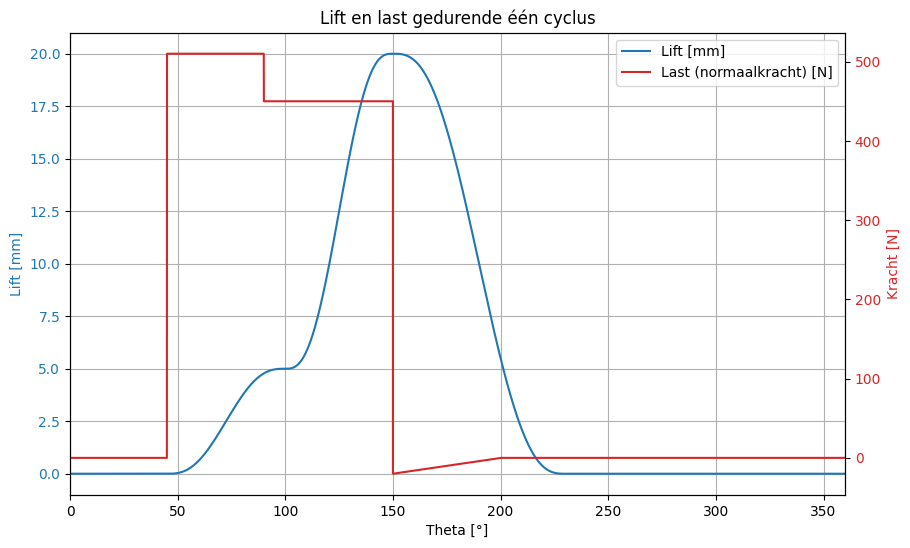

In [45]:
# lift en kracht plotten voor één cyclus:
plt.figure(figsize=(10, 6))
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(theta_deg, lift, color='tab:blue', label='Lift [mm]')
ax1.set_xlabel('Theta [°]')
ax1.set_ylabel('Lift [mm]', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xlim([0, 360])
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(theta_deg, ext_load, color='tab:red', label='Last (normaalkracht) [N]')
ax2.set_ylabel('Kracht [N]', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Lift en last gedurende één cyclus')
plt.show()


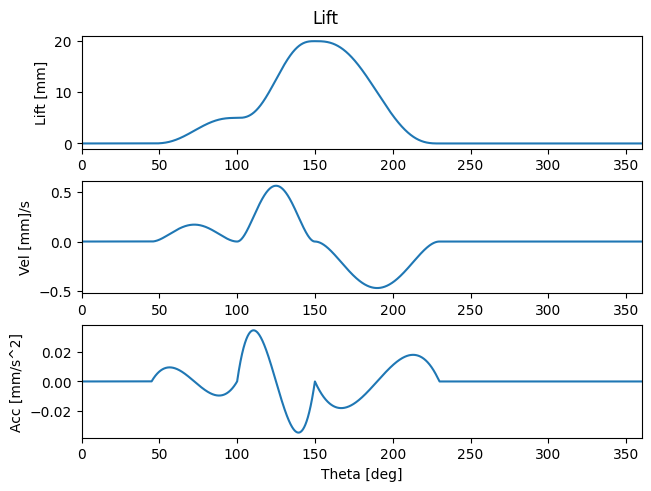

In [46]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])


# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)
lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)
#lift, vel_deg, acc_deg, vel, acc = addMotionSegment(startangle4,endangle4,startlift4,endlift4,motionlaw4,dtheta)


# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg)

plt.show()

In [47]:
# utility functions for external load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [°]')
    plt.ylabel('Externe belasting [N]')
    plt.xlim([0,360])
    plt.title('Externe belasting')


In [48]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'segment span: %s°'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (degrees)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()


In [49]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    angle_deg = pressure_angle*180/np.pi
    plt.figure()
    plt.plot(theta_deg, angle_deg)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

    angle_max = np.max(angle_deg)
    angle_min = np.min(angle_deg)
    plt.axhline(angle_max, color='r', linestyle='--', linewidth=0.8)
    plt.axhline(angle_min, color='g', linestyle='--', linewidth=0.8)
    plt.text(5, angle_max + 1, f'max = {angle_max:.2f}°', color='r')
    plt.text(5, angle_min - 1, f'min = {angle_min:.2f}°', color='g')

In [50]:
# utility functions for curvature radius, cam countour and forces

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam, follower_radius):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.axhline(follower_radius, color='r', linestyle='--', linewidth=0.8)
    plt.xlabel('Theta [°]')
    plt.ylabel('Kromtestraal [mm]')
    plt.xlim([0,360])
    plt.legend(['Kromtestraal steekkromme', 'Kromtestraal nokprofiel', 'Straal van de volger'])
    plt.ylim([-200,300])
    plt.grid()
    plt.title('Kromtestraal van de steekkromme en het nokprofiel')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]
    xcam_closed = np.append(xcam, xcam[0])
    ycam_closed = np.append(ycam, ycam[0])


    # Bereken de oppervlakte mét teken voor de formule
    signed_area = 0.5 * np.sum(xcam_closed[:-1] * ycam_closed[1:] - xcam_closed[1:] * ycam_closed[:-1])
    
    # Gebruik de signed_area voor X en Y
    centroid_x = (1 / (6 * signed_area)) * np.sum(
        (xcam_closed[:-1] + xcam_closed[1:]) *
        (xcam_closed[:-1] * ycam_closed[1:] - xcam_closed[1:] * ycam_closed[:-1])
    )
    centroid_y = (1 / (6 * signed_area)) * np.sum(
        (ycam_closed[:-1] + ycam_closed[1:]) *
        (xcam_closed[:-1] * ycam_closed[1:] - xcam_closed[1:] * ycam_closed[:-1])
    )

    # Neem de absolute waarde voor de weergave en latere berekeningen
    polygon_area = np.abs(signed_area)
    cam_excentricity = np.sqrt(centroid_x**2 + centroid_y**2)

    plt.scatter(centroid_x, centroid_y, color='k', s=20, zorder=5)
    plt.text(
        centroid_x, centroid_y, 'CG',
        fontsize=8, color='k', ha='left', va='bottom'
    )

    plt.text(
        0.02, 0.98,
        f'Oppervlakte nok: {polygon_area:.1f} mm²\nExcentriciteit massacentrum: {cam_excentricity:.2f} mm',
        transform=plt.gca().transAxes,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', linewidth=0.5)
    )
    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Nokprofiel [mm]')

    return polygon_area, cam_excentricity

def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.xlabel('Theta [°]')
    plt.ylabel('Kracht [N]')
    plt.xlim([0,360])
    plt.legend(['totaal','acc','last','veer'])
    plt.title('Normaalkracht')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [°]')
    plt.ylabel('Kracht x [N]')
    plt.xlim([0,360])
    plt.title('Kracht x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [°]')
    plt.ylabel('Kracht y [N]')
    plt.xlim([0,360])
    plt.title('Kracht y')


### Ontwerp van minimale steekcirkel $R_0$

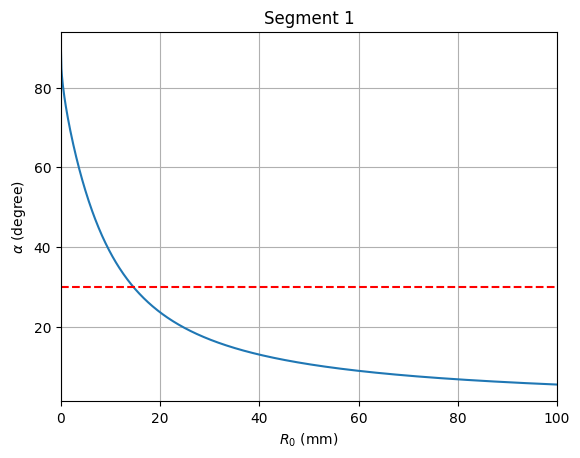

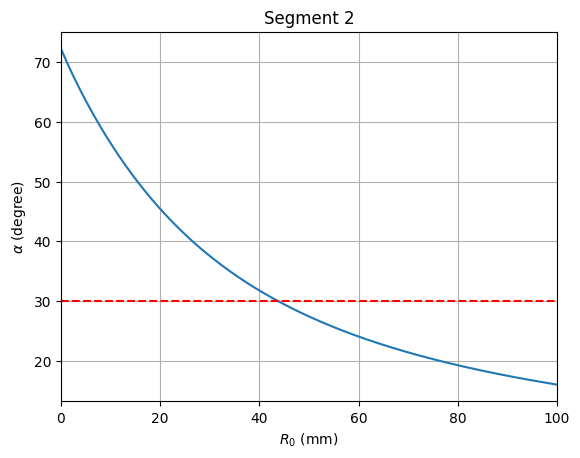

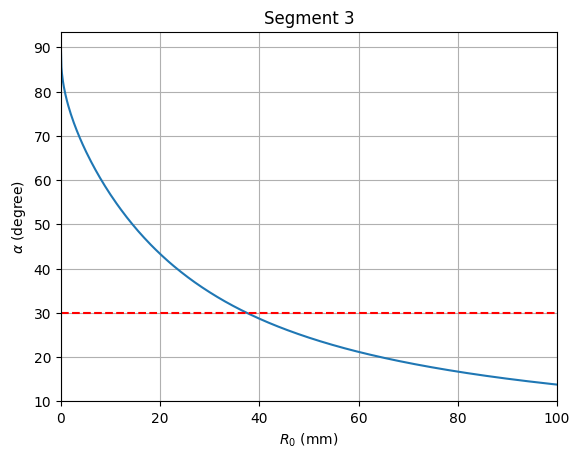

In [51]:
# parameter values for the needed motion segments

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

# The approach was first described by M. Kloomok and R.V. Muffley,
# in Chapter 3 of Mabie, H.H., and Ocvirk, F.W., Mechanisms and Dynamics of Machinery, 1957

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2

    return lift, vel_deg, acc_deg, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

# segment 1:
Kloomok_Muffley_R0(theta_seg1,startlift1,endlift1,motionlaw1)

plt.plot(R0_vec, alpha_max)
plt.axhline(y=30, color='r', linestyle='--', label='α = 30°')  # ← Toegevoegd
plt.grid()
plt.title('Segment 1')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 2:
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.axhline(y=30, color='r', linestyle='--', label='α = 30°')  # ← Toegevoegd
plt.grid()
plt.title('Segment 2')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 3:
Kloomok_Muffley_R0(theta_seg3,startlift3,endlift3,motionlaw3)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.axhline(y=30, color='r', linestyle='--', label='α = 30°')  # ← Toegevoegd
plt.grid()
plt.title('Segment 3')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()


Uit bovenstaande plots besluiten we dat $R_0 = 60\text{mm}$ een geschikte waarde is.
<br>
(Op basis van de vuistregel dat de maximum drukhoek $\alpha_{\text{max}}$ best onder de 30 graden blijft)
<br>
50 mm zou ook moeten gaan, maar om de drukhoek laag te houden wordt een extra grote $R_0$ verkozen.


In [52]:
R0 = 60  # steekcirkel in mm 

### Ontwerp van straal $R_r$ van de volger

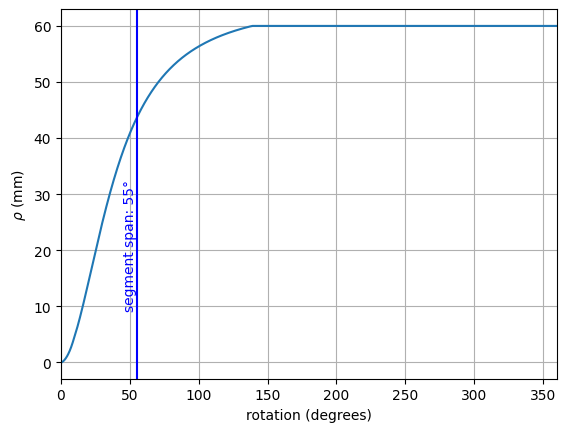

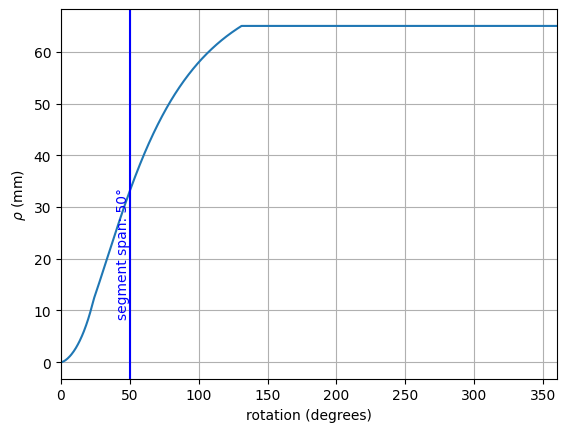

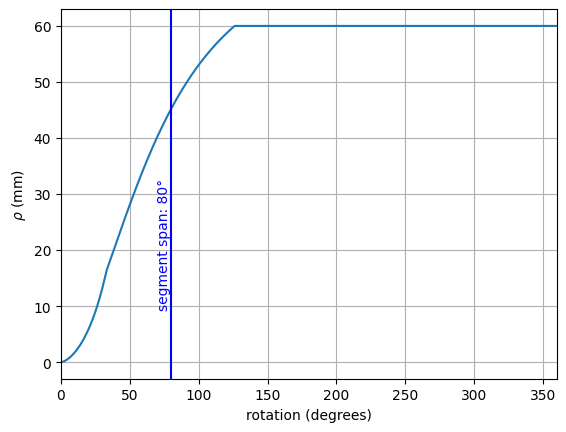

In [53]:
# compute R_r for all segments:

Kloomok_Muffley_follower_radius(R0,theta_seg1,startlift1,endlift1,motionlaw1)
Kloomok_Muffley_follower_radius(R0,theta_seg2,startlift2,endlift2,motionlaw2)
Kloomok_Muffley_follower_radius(R0,theta_seg3,startlift3,endlift3,motionlaw3)


In de bovenstaande plots is het mogelijk te zien dat de straak van de volger $R_r$ kleiner moet zijn dat respectievelijk $40$ mm (segment 1),
$30$ mm (segment 2) en $40$ mm (segment 3).  We kiezen $R_r = 15$ mm. De basiscirkel van de nok is dan $R_0 - R_r = 45$ mm. Later wordt duidelijk dat de kleine volgradius niet voor problemen met de contactdruk zorgt.

minimale kromming vand het nokprofiel: 16.07 mm


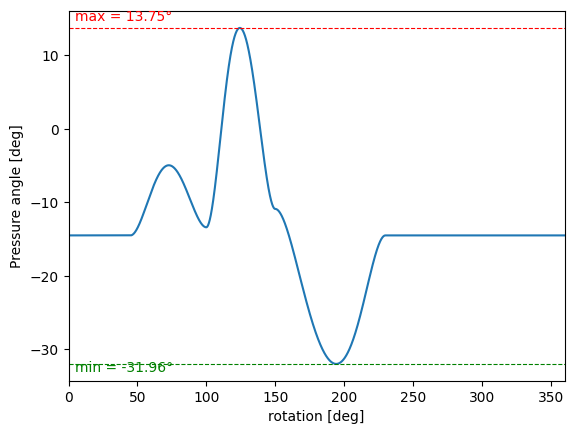

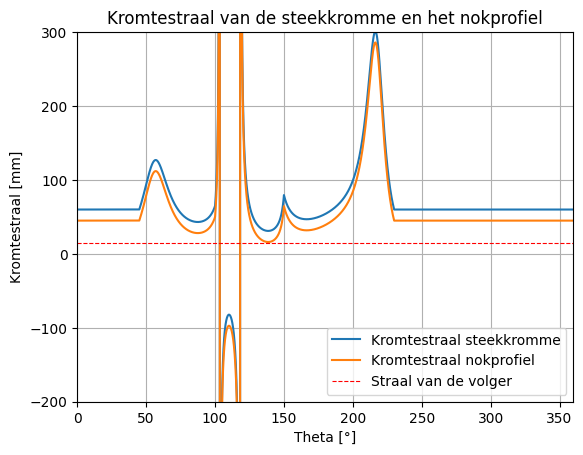

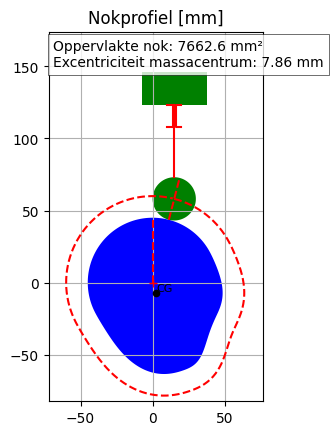

In [54]:
# Kinematics inputs
follower_radius =15
base_radius = R0 - follower_radius
exc = 15 # (excentriciteit, aangepast voor kleine piek-Fx) -> 12 mm voor alfa < 30°

# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)
# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)

min_roc_cam = np.min(np.abs(roc_cam))
print(f'minimale kromming vand het nokprofiel: {min_roc_cam:.2f} mm')

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam, follower_radius)

# Plot the cam contour
[opp_nok, excentriciteit_nok] = plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta)

De voorwaarde voor het vermijden van ondersnijding is $\rho_{min} > R_r$; de kromtestraal van de steekkromme moet steeds groter zijn dan de straal van de volger, wat betekent dat de kromtestraal van de nok groter dan 0 is. In de kromtestraal-grafiek is zichtbaar dat dit het geval is

### Dynamica

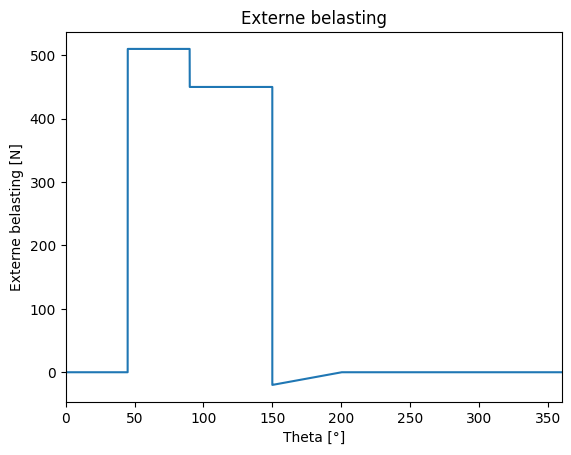

In [55]:
plotExternalLoad(theta_deg,ext_load)

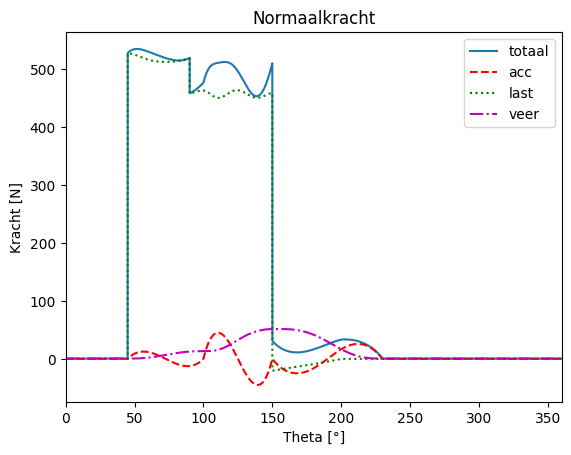

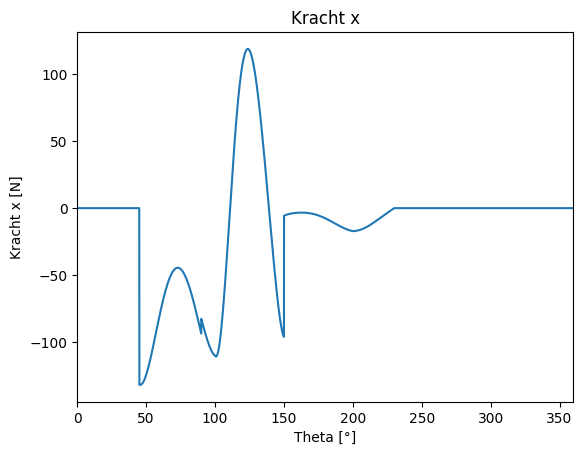

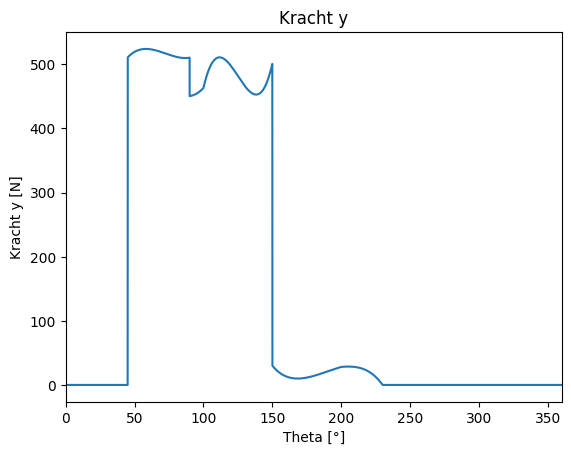

In [56]:
# spring design

# dynamic inputs
mass            =  10 # 10 kg
spring_constant =  2.5 # N/m
spring_preload  = 0.5 # N (niet strikt nodig, klein gekozen)
rpm             = 60/1 # 1s per cyclus

# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)
min_total_force = np.min(normalforce_tot)
max_total_force = np.max(normalforce_tot)
color = 'green' if min_total_force >= 0 else 'red'

display(HTML(f"<p style='color:{color}; font-weight:bold;'>Minimale totale kracht = {min_total_force:.3f} N</p>"))

### Onbalans-analyse

De onbalans wordt gedefinieerd als $e \cdot m$, met $e$ de excentriciteit van de nok, en $m$ de massa ervan. Om de massa te kennen van de nok, is het echter nodig om de breedte van de nok te kiezen. Dit wordt gedaan met de volgende formule:

$$L = \frac{F \cdot E^*}{\pi \cdot R^* \cdot p_{toel}^2}$$

**Waarin:**
*   $L$ = Minimale contactbreedte (mm)
*   $F$ = Maximale normaalkracht (N)
*   $p_{toel}$ = Toelaatbare Hertzse spanning (MPa of N/mm²). Hier gelijk genomen aan de treksterkte $R_{Mn}$ = 360 MPa (voor S235 JR)
*   $R^*$ = Effectieve kromtestraal (mm) met: $$\frac{1}{R^*} = \frac{1}{\rho_{min, nok}} + \frac{1}{R_{volger}}$$
*   $E^*$ = Effectieve elasticiteitsmodulus (MPa of N/mm²), afhankelijk van de elasticiteitsmodulus ($E$) en de Poisson-factor ($\nu$) van beide materialen:

$$\frac{1}{E^*} = \frac{1 - \nu_{nok}^2}{E_{nok}} + \frac{1 - \nu_{volger}^2}{E_{volger}}$$

Voor een stalen nok en stalen volger ($E \approx 210~000$ MPa, $\nu \approx 0,3$) vereenvoudigt dit tot:

$$E^* \approx 115~385 \text{ MPa}$$

In [57]:
#minimale breedte berekenen
E = 115385 # MPa (staal)
Reff = 1/(1/min_roc_cam + 1/follower_radius) # effectieve straal van de nok-volger combinatie
p_max = 360 # MPa (toelaatbare Hertzse spanning)

L = max_total_force*E/(np.pi*Reff*p_max**2)
print(f'Benodigde breedte L volgens Hertzse contactformule: {L:.2f} mm')

Benodigde breedte L volgens Hertzse contactformule: 19.52 mm


De minimale breedte is dus 19.52 mm, we kiezen voor 25 mm (de berekeningen zijn simplistisch, een marge is gewenst). De massa van de nok is dan $A \cdot L \cdot \rho_{staal}$, met $A$ de voorheen berekende oppervlakte van de nok.

In [58]:
#onbalans berekenen
rho_staal = 7850 # kg/m^3
massa_nok = rho_staal * L * opp_nok * 1e-6 # g
onbalans = massa_nok * excentriciteit_nok  # g*mm 
print(f'Massa van de nok: {massa_nok:.2f} g')
print(f'Onbalans van de nok: {onbalans:.2f} g*mm')
md(f"<span style='font-size: 17px; font-family: inherit;'>De massa van de nok is {massa_nok:.2f} g en de onbalans is dus {onbalans:.1f} g*mm.</span>")


Massa van de nok: 1174.23 g
Onbalans van de nok: 9232.08 g*mm


<span style='font-size: 17px; font-family: inherit;'>De massa van de nok is 1174.23 g en de onbalans is dus 9232.1 g*mm.</span>

In [59]:
#centrifugale kracht berekenen
F_centrifugaal = onbalans * (rpm*2*np.pi/60)**2 * 1e-6 # N
print(f'Centrifugale kracht door de nokmassa: {F_centrifugaal:.4f} N')
md(f"<span style='font-size: 17px; font-family: inherit;'>Bij een cycluslengte van 1 seconde is de centrifugale kracht door de nokmassa F = m *e *omega² = {F_centrifugaal:.3f} N.</span>")


Centrifugale kracht door de nokmassa: 0.3645 N


<span style='font-size: 17px; font-family: inherit;'>Bij een cycluslengte van 1 seconde is de centrifugale kracht door de nokmassa F = m *e *omega² = 0.364 N.</span>

In [60]:
# Automatische checks voor nokontwerp

checks_passed = True
issues = []

# 1. Check voor ondersnijding (rho_min > R_r)
if min_roc_cam > follower_radius:
    issues.append(f"✓ Ondersnijding: OK (ρ_min = {min_roc_cam + follower_radius:.2f} mm > R_r = {follower_radius} mm)")
else:
    issues.append(f"✗ Ondersnijding: FOUT (ρ_min = {min_roc_cam:.2f} mm ≤ R_r = {follower_radius} mm)")
    checks_passed = False

# 2. Check voor maximale drukhoek < 35°
pressure_angle_deg = np.abs(pressure_angle * 180 / np.pi)
max_pressure_angle = np.max(pressure_angle_deg)
if max_pressure_angle < 30:
    issues.append(f"✓ Drukhoek: OK (α_max = {max_pressure_angle:.2f}° < 30°)")
else:
    issues.append(f"✗ Drukhoek: FOUT (α_max = {max_pressure_angle:.2f}° ≥ 30°)")
    checks_passed = False

# 3. Check voor steeds positieve normaalkracht (druk)
if min_total_force >= 0:
    issues.append(f"✓ Normaalkracht: OK (F_min = {min_total_force:.2f} N ≥ 0 N)")
else:
    issues.append(f"✗ Normaalkracht: FOUT (F_min = {min_total_force:.2f} N < 0 N - loshechting gedetecteerd)")
    checks_passed = False

# 4. Check voor kleine onbalanskracht (< 1 N)
if F_centrifugaal < 1:
    issues.append(f"✓ Onbalanskracht: OK (F_centrifugaal = {F_centrifugaal:.4f} N < 1 N)")
else:
    issues.append(f"✗ Onbalanskracht: FOUT (F_centrifugaal = {F_centrifugaal:.4f} N ≥ 1 N)")
    checks_passed = False

# Display results
print("\n" + "="*60)
print("AUTOMATISCHE CHECKS NOKONTWERP")
print("="*60)
for issue in issues:
    print(issue)
print("="*60)

# Overall result
if checks_passed:
    display(HTML("<h3 style='color:green;'>✓ ALLE CHECKS GESLAAGD - ONTWERP OK</h3>"))
else:
    display(HTML("<h3 style='color:red;'>✗ ENKELE CHECKS MISLUKT </h3>"))


AUTOMATISCHE CHECKS NOKONTWERP
✓ Ondersnijding: OK (ρ_min = 31.07 mm > R_r = 15 mm)
✗ Drukhoek: FOUT (α_max = 31.96° ≥ 30°)
✓ Normaalkracht: OK (F_min = 0.52 N ≥ 0 N)
✓ Onbalanskracht: OK (F_centrifugaal = 0.3645 N < 1 N)


### Ontwerp van een vliegwiel & motorkeuze



Eerst moet men een maximale fluctuatie $K$ kiezen. Op basis van de onderstaande tabel wordt $K = 0.15$ gekozen (cf. power press).
<figure style="display: grid; place-items: center; place-content: center; margin: 0;">
  <!-- Neemt nu 50% van de breedte van de ouder-container in -->
  <img style="border: 0; display: inline-block; width: auto; height: 100%;" 
       src="images/speed fluctuation.webp" 
       alt="Speed fluctuation met vliegwiel">
  <figcaption style="font-size: 0.85em; color: #555; margin-top: 1px; text-align: center;">
    Bron: <a href="https://medium.com/@harsh.shet20/fig-torque-time-relation-with-a-flywheel-54fae021e458" target="_blank" rel="noopener noreferrer">Harsh Shet via Medium</a>
  </figcaption>
</figure>

Gemiddeld koppel over de cyclus: 1.66 Nm


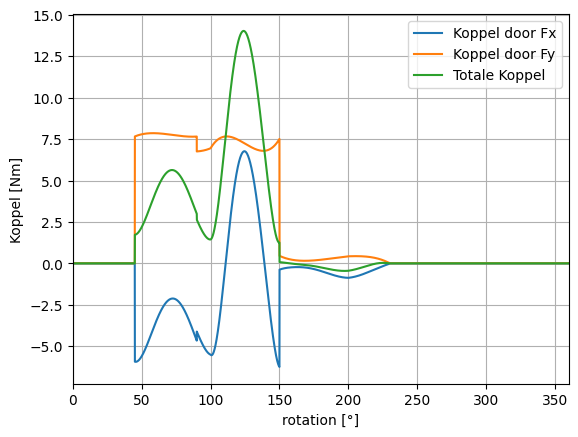

In [61]:
Ty = exc/1000 * force_y # koppel van Fx in Nm
Tx =  force_x * (lift+ base_radius)/1000 # koppel van Fy in Nm
T_tot = Tx + Ty
T_avg = np.mean(T_tot)

plt.figure()
plt.plot(theta_deg, Tx, label='Koppel door Fx')
plt.plot(theta_deg, Ty, label='Koppel door Fy')
plt.plot(theta_deg, T_tot, label='Totale Koppel')
plt.xlabel('rotation [°]')
plt.ylabel('Koppel [Nm]')
plt.xlim([0,360])
plt.legend()
plt.grid()

print(f'Gemiddeld koppel over de cyclus: {T_avg:.2f} Nm')

Maximale arbeidssurplus A = 6.326 J


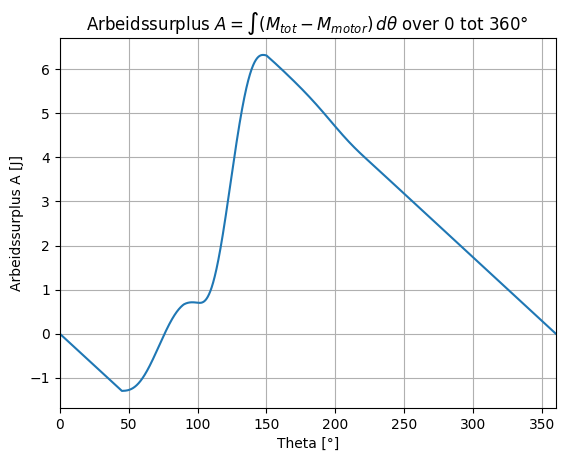

In [62]:
#arbeidssurplus berekenen
A = np.zeros_like(theta)
torque_diff = T_tot - T_avg
A[1:] = np.cumsum((torque_diff[:-1] + torque_diff[1:]) / 2 * np.diff(theta))

plt.figure()
plt.plot(theta_deg, A)
plt.xlabel('Theta [°]')
plt.ylabel('Arbeidssurplus A [J]')
plt.title(r'Arbeidssurplus $A = \int (M_{tot} - M_{motor})\, d\theta$ over 0 tot 360°')
plt.xlim([0, 360])
plt.grid(True)

max_A = np.max(A)
print(f'Maximale arbeidssurplus A = {max_A:.3f} J')

Uit de bovenstaande grafiek is het zichtbaar dat het piekkoppel veel groter is dat het gemiddelde koppel dat de motor moet leveren. In dat geval is het zeer logisch om een vliegwiel te installeren, omdat we een veel minder krachtige motor kunnen kiezen.

De inertie van het vliegwiel wordt, in overeenkomst met Les 4, via de volgende formule berekend:
\begin{equation*}
 I = \frac{\int_{\theta_{m}}^{\theta_{M}} (M_{tot} - M_motor) d\theta}{K \omega^2_{\text{av}}}.
\end{equation*}

Met: 
- $M_{tot}$: het totale koppel dat de nok moet leveren
- $M_{motor}$: het koppel dat de motor moet leveren, hier gelijk genomen aan het gemiddelde koppel over de cyclus
- $\theta_m$ en $\theta_M$: de hoek waarbij respectievelijk de minimale en maximale
- $K$: de maximale fluctuatie, eerder 0.15 gekozen
- $\omega_{av}$: de gemiddelde hoeksnelheid, bepaald door de cycluslengte

In [63]:
K = 0.15

omega_av = rpm * 2 * np.pi / 60  # rad/s
I = max_A / (K * omega_av**2)

print(f'Benodigde vliegwielinertie I = {I:.3f} kg·m²')

Benodigde vliegwielinertie I = 1.068 kg·m²


Aan de hand van de gevonden inertie is het mogelijk om het vliegwiel te dimensioneren. Voor de eenvoud en lage productiekosten wordt er een stalen schijf-vliegwiel gekozen. De straal wordt tot 300 mm beperkt, al moet dit volgens de gevallen worden aangepast aan de specifieke inbouwruimte.
De dikte is dan:
$t = \frac{2I}{\pi R^4 \rho}$

In [64]:
R = 300  # mm

R_m = R * 1e-3  # omzetten naar meter
t = 2 * I / (np.pi * R_m**4 * rho_staal)  # dikte in meter
t_mm = t * 1e3  # omzetten naar mm

print(f"Voor R = {R} mm is de dikte t = {t_mm:.2f} mm")

Voor R = 300 mm is de dikte t = 10.70 mm


Alternatief kan met de dikte i.f.v. de straal plotten, en een redelijke compromiswaarde kiezen:

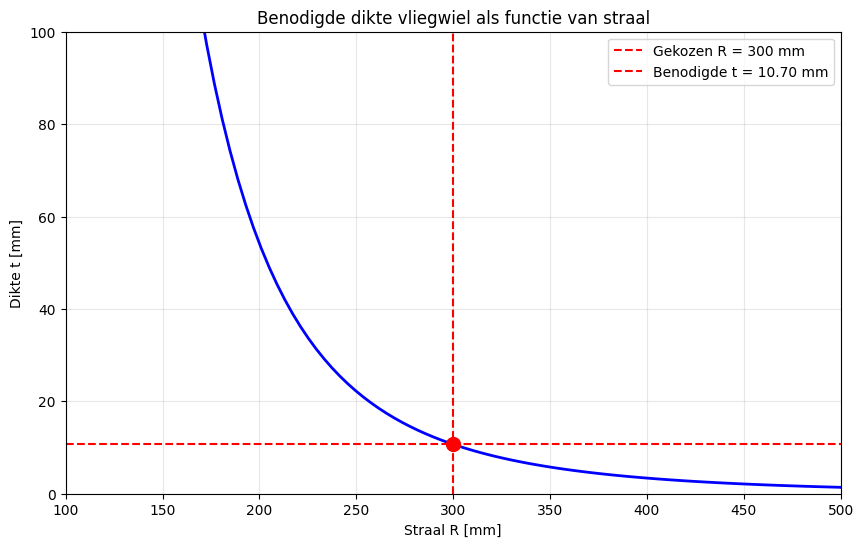

In [65]:
# benodigde dikte t als functie van straal R
R_range = np.linspace(100, 500, 100)  # Straal van 100 tot 500 mm
t_range = 2 * I / (np.pi * (R_range * 1e-3)**4 * rho_staal) * 1e3  # Dikte in mm

plt.figure(figsize=(10, 6))
plt.plot(R_range, t_range, 'b-', linewidth=2)
plt.axvline(x=R, color='r', linestyle='--', label=f'Gekozen R = {R} mm')
plt.axhline(y=t_mm, color='r', linestyle='--', label=f'Benodigde t = {t_mm:.2f} mm')
plt.scatter([R], [t_mm], color='r', s=100, zorder=5)
plt.xlabel('Straal R [mm]')
plt.ylabel('Dikte t [mm]')
plt.title('Benodigde dikte vliegwiel als functie van straal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([100, 500])
plt.ylim([0, 100])
plt.show()

De massa hangt dan af van de gekozen straal R en de bijbehorende dikte t.

In [66]:
t = 11e-3  # dikte in meter
mass_flywheel = np.pi * R_m**2 * t * rho_staal
mass_flywheel_g = mass_flywheel * 1e3

print(f"Vliegwielmassa voor t = {t*1e3:.0f} mm: {mass_flywheel:.3f} kg")

Vliegwielmassa voor t = 11 mm: 24.415 kg


Dankzij het vliegwiel moet de motor dus continu het gemiddelde koppel leveren. Men moet dus een motor selecteren met een 'rated torque' dat hieraan voldoet. Alternatief kan men kiezen voor een motor dat het meest efficiënt is bij dit koppel. Echter, met electriciteitsprijzen rond de €0,40/kWh zal de kost aan electriciteit waarschijnlijk een groottorde kleiner zijn t.o.v. de aanschafprijs van de motor.

Gezien de lage toerentallen is het gebruik van een reductiekast te verkiezen. Daarom is het interessanter te kijken naar het benodigde vermogen. 

In [67]:
power_W = T_avg * omega_av
power_kW = power_W / 1000

print(f'Benodigd koppel: {T_avg:.3f} Nm')
print(f'Toerental: {rpm:.1f} rpm')
print(f'Benodigd vermogen: {power_W:.3f} W')

Benodigd koppel: 1.656 Nm
Toerental: 60.0 rpm
Benodigd vermogen: 10.403 W


Een motor die hieraan voldoet, is de Dunkermotor [BG 32x10 KI][1], gekoppeld aan een [PLG 42 K planetaire tandwielkast][2]. De motor heeft een nominaal vermogen van 18 W. 
Voor een reductiefactor van 64 heeft de tandwielkast een efficiëntie van 81%. Met deze reductiefactor kan de motor op zijn nominaal toerental draaien, waarbij 2.31 Nm beschikbaar is.

<table style="width: 50%; border: none;">
  <tr style="border: none;">
    <td style="width: 50%; border: none; text-align: center;">
      <img src="Images/BG 32.png" alt="Links" width="100%">
    </td>
    <td style="width: 50%; border: none; text-align: center;">
      <img src="Images/PLG 32.png" alt="Rechts" width="100%">
    </td>
  </tr>
</table>

[1]: https://ametekcdn.azureedge.net/mediafiles/project/oneweb/oneweb/dunkermotoren/downloads/pdf/products/new/motors/bg/dgo/bg%2032%20ki_en_1.pdf?revision:56a16fd7-cd67-4a92-a30f-33263a95fce0
[2]: https://ametekcdn.azureedge.net/mediafiles/project/oneweb/oneweb/dunkermotoren/downloads/pdf/products/new/gearboxes/plg/plg%2042%20k_en_1.pdf?revision:e4352136-d42f-4648-bef9-00952bfd446e

In [68]:
motor_power_rated = 18.0  # W
gearbox_efficiency = 0.81

omega_final = rpm * 2 * np.pi / 60  # rad/s
torque_available = motor_power_rated * gearbox_efficiency / omega_final

time_to_speed = I * omega_final / torque_available
print(f"Tijd om op te lopen naar {rpm:.1f} rpm vanuit rust: {time_to_speed:.2f} s")

Tijd om op te lopen naar 60.0 rpm vanuit rust: 2.89 s


Dunkermotoren hanteert geen openbare consumentenprijzen, maar gelijkaardige onderdelen op de secundaire markt geven een indicatie van een prijs in de honderden euros. 

Het is interessant om dit te vergelijken met de elektriciteitskosten. Als men een motorefficiëntie van 60% beschouwt, kan men via het gemiddelde koppel en de efficiëntie van de tandwielkast (81%) het elektriciteitsverbruik berekenen. Dit doet men voor 40u/week, 52 weken/jaar.
Volgens [Eneco](https://eneco.be/nl/inspiratie/hoeveel-kost-1-kwh-elektriciteit-en-gas-gemiddeld/) was de gemiddelde elektriciteitsprijs in april 2025 €0,38/kWh (voor consumenten weliswaar).

In [ ]:
# Elektriciteitskost berekening over 5 jaar

# Parameters
years = 5
weeks_per_year = 52
hours_per_week = 40
motor_efficiency = 0.60  # 60% motor efficiency
electricity_price = 0.38  # €/kWh (April 2025)

# Berekening totale bedrijfsuren
total_hours = years * weeks_per_year * hours_per_week

# Elektrisch vermogen input (rekening houdend met motor- en tandwielkastrendement)
electrical_power_input = power_W / (motor_efficiency * gearbox_efficiency)  # W
electrical_power_input_kW = electrical_power_input / 1000

# Totaal elektriciteitsverbruik
total_energy_kWh = electrical_power_input_kW * total_hours

# Totale kosten
total_cost_euros = total_energy_kWh * electricity_price

# Flessen per cyclus en totaal aantal flessen
# 1 cyclus = 1 seconde en drukt 2 kurken (dus 2 flessen)
bottles_per_cycle = 2
cycles_per_second = 1 / (1 / rpm * 60)  # rpm is aantal rotaties per minuut
bottles_per_hour = bottles_per_cycle * cycles_per_second * 3600
total_bottles = bottles_per_hour * total_hours

# Output
print("="*60)
print("ELEKTRICITEITSKOST OVER 5 JAAR")
print("="*60)
print(f"Bedrijfsperiode: {years} jaar ({weeks_per_year} weken/jaar, {hours_per_week} uren/week)")
print(f"\nMotor vermogen (mechanisch): {power_W:.3f} W")
print(f"Elektrisch vermogen (input): {electrical_power_input:.3f} W ({electrical_power_input_kW:.6f} kW)")

print(f"\nTotaal energieverbruik: {total_energy_kWh:.2f} kWh")
print(f"Totale elektriciteitskost: €{total_cost_euros:.2f}")
print(f"Totaal aantal flessen in {years} jaar: {total_bottles:.0f}")
print(f"Elektriciteitskost per fles: €{total_cost_euros/total_bottles}")
print("="*60)

ELEKTRICITEITSKOST OVER 5 JAAR
Bedrijfsperiode: 5 jaar (52 weken/jaar, 40 uren/week)

Motor vermogen (mechanisch): 10.403 W
Elektrisch vermogen (input): 21.406 W (0.021406 kW)

Totaal energieverbruik: 222.62 kWh
Totale elektriciteitskost: €84.60
Totaal aantal flessen in 5 jaar: 74880000
Elektriciteitskost per fles: €1.1297596000634182e-06


Men kan dus concluderen dat de elektriciteitskosten aanzienlijk minder belangrijk zijn dan de investeringskost in de motor. Eventueel kan men een minder efficiënte, maar goedkopere motor selecteren. Men kan zich ook afvragen of het niet beter zou zijn om de hele productieband met één motor aan de sturen, om de synchronisatie te versimpelen.

### Bronnen

Formule Hertze contactspanning volgens Hertz:
Wittel, H., Jannasch, D., Voßiek, J., & Spura, C. (2021). *Roloff/Matek Machineonderdelen: Theorieboek* (6e druk). Boom Uitgevers.

Treksterkte S235 JR:
Wittel, H., Jannasch, D., Voßiek, J., & Spura, C. (2021). *Roloff/Matek Machineonderdelen: Tabellenboek* (6e druk). Boom Uitgevers.

Treksterkte als toelaatbare Hertze spanning:
Euro-Bearings. (s.d.). *Hertzian pressure for combined roller bearings*. Geraadpleegd op 18 mei 2026, van https://www.euro-bearings.com/calc2.htm

Maximale fluctuatie:
Shet, H. (2022, 27 november). *Flywheel Torque Fluctuation*. Medium. https://medium.com/@harsh.shet20/fig-torque-time-relation-with-a-flywheel-54fae021e458

Documentatie Dunkermotor BG 32x10 KI
Dunkermotoren. (s.d.). *BG 32 KI* [Datasheet]. Geraadpleegd op 18 mei 2026, van https://ametekcdn.azureedge.net/mediafiles/project/oneweb/oneweb/dunkermotoren/downloads/pdf/products/new/motors/bg/dgo/bg%2032%20ki_en_1.pdf:

Documentatie Dunkermotor PLG 42 K:
Dunkermotoren. (s.d.). *PLG 42 K* [Datasheet]. Geraadpleegd op 18 mei 2026, van https://ametekcdn.azureedge.net/mediafiles/project/oneweb/oneweb/dunkermotoren/downloads/pdf/products/new/gearboxes/plg/plg%2042%20k_en_1.pdf

Elektriciteitskost: 
Eneco. (s.d.). *Hoeveel kost 1 kWh elektriciteit en gas gemiddeld?* Geraadpleegd op 18 mei 2026, van https://eneco.be/nl/inspiratie/hoeveel-kost-1-kwh-elektriciteit-en-gas-gemiddeld/
